In [17]:
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", message="numpy.dtype size changed")

import dynamo as dyn
dyn.configuration.set_figure_params('dynamo', background='white')
dyn.pl.style(font_path='Arial')

Using already downloaded Arial font from: /var/folders/_0/8l2kpxvj13b9xcgqzjm3mkjw0000gn/T/dynamo_arial.ttf
Registered custom font as: Arial


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

In [19]:
adata_36=dyn.read_h5ad('results/adata_nmda36_dynamo.h5ad')

In [20]:
adata_72=dyn.read_h5ad('results/adata_nmda72_dynamo.h5ad')

In [21]:
color_key_dict = {
    'Progenitor': '#00CED1',  
    'Amacrine': '#E31A1C',
    'Bipolar': '#A6D854',   
    'Rod': '#FDBF6F',        
    'Müller': '#1F78B4',   
    'Ganglion': '#FB9A99',   
    'Horizontal': '#6A3D9A',  
    'RPE': '#B15928',         
    'Red Cone': '#FF0000',   
    'Green Cone': '#00FF00', 
    'Blue Cone': '#0000FF',   
    'UV Cone': '#9400D3',     
    'Macrophage': '#FF00FF'    
}

In [22]:
def velocity(query_pos, vf):
    # Euclidean distance squared
    dist_sq = np.sum(query_pos**2, axis=1).reshape(-1, 1) + np.sum(vf['X_ctrl']**2, axis=1) - 2 * np.dot(query_pos, vf['X_ctrl'].T)
    
    # Gaussian kernel
    K = np.exp(-vf['beta'] * dist_sq)
    
    # Velocity at query point
    V = np.dot(K, vf['C'])
    
    return V

def simulate_paths(init_pos, vf_start, vf_end, dt):
    traj = [init_pos]
    current_pos = np.copy(init_pos)

    for i in range(100): # Interporlate over 100 steps
        s = i / 100
        
        # get velocity from the starting and ending timepoint models
        v_start = velocity(current_pos, vf_start)
        v_end = velocity(current_pos, vf_end)
        
        v_interp = (1 - s) * v_start + s * v_end

        current_pos += v_interp * dt
        traj.append(np.copy(current_pos))
        
    return np.array(traj)

Optimal k: 1.11
Max overlap score: 0.0065


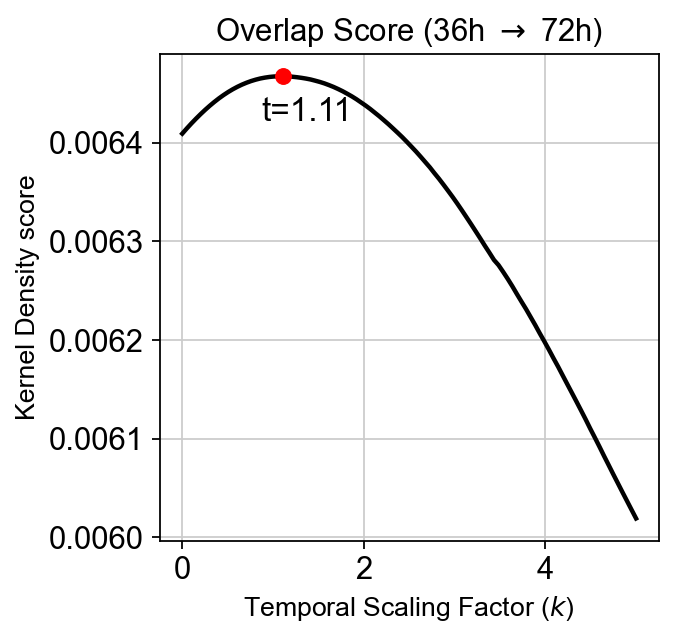

: 

In [25]:
def find_optimal_k(init_pos, vf_start, vf_end, ref_adata):
    
    # candidate scaling factors
    candidate_ks = np.linspace(0, 5, 100)
    
    best_k = None
    max_score = -np.inf
    scores = []

    non_prog = [cell for cell in ref_adata.obs['Cell_type'].unique() if cell not in ['Progenitor']]
    ref = ref_adata.obsm['X_umap'][ref_adata.obs['Cell_type'].isin(non_prog)].T
    
    # calculate Gaussian KDE of reference
    kde_ref = gaussian_kde(ref)

    for k in candidate_ks:
        scaled_dt = 0.01 * k
        paths = simulate_paths(init_pos, vf_start, vf_end, scaled_dt)
        endpoints = paths[-1] 
        
        density_values = kde_ref(endpoints.T)
        
        # calculate mean Gaussian KD score
        mean_score = np.mean(density_values)
        scores.append(mean_score)

        if mean_score > max_score:
            max_score = mean_score
            best_k = k

    print(f"Optimal k: {best_k:.2f}")
    print(f"Max overlap score: {max_score:.4f}")

    plt.plot(candidate_ks, scores, linestyle='-', color='k', linewidth=2)

    plt.scatter(best_k, max_score, color='r', s=50, zorder=5, label=f'$k$ = {best_k:.2f}')

    plt.annotate(
        f't={best_k:.2f}', 
        xy=(best_k, max_score), 
        xytext=(-10, -20), 
        textcoords='offset points', 
        fontsize=15)

    plt.xlabel('Temporal Scaling Factor ($k$)', fontsize=12)
    plt.ylabel('Kernel Density score', fontsize=12)
    plt.title("Overlap Score (36h $\\rightarrow$ 72h)")
    
    return best_k

np.random.seed(42)
init_cells = adata_36.obsm['X_umap'][np.random.choice(adata_36.n_obs, 500, replace=False)]

optimal_k = find_optimal_k(
    init_pos=init_cells, 
    vf_start=adata_36.uns['VecFld_umap'],
    vf_end=adata_72.uns['VecFld_umap'],
    ref_adata=adata_72
)

|-----------> plotting with basis key=X_umap
|-----------> skip filtering Cell_type by stack threshold when stacking color because it is not a numeric type


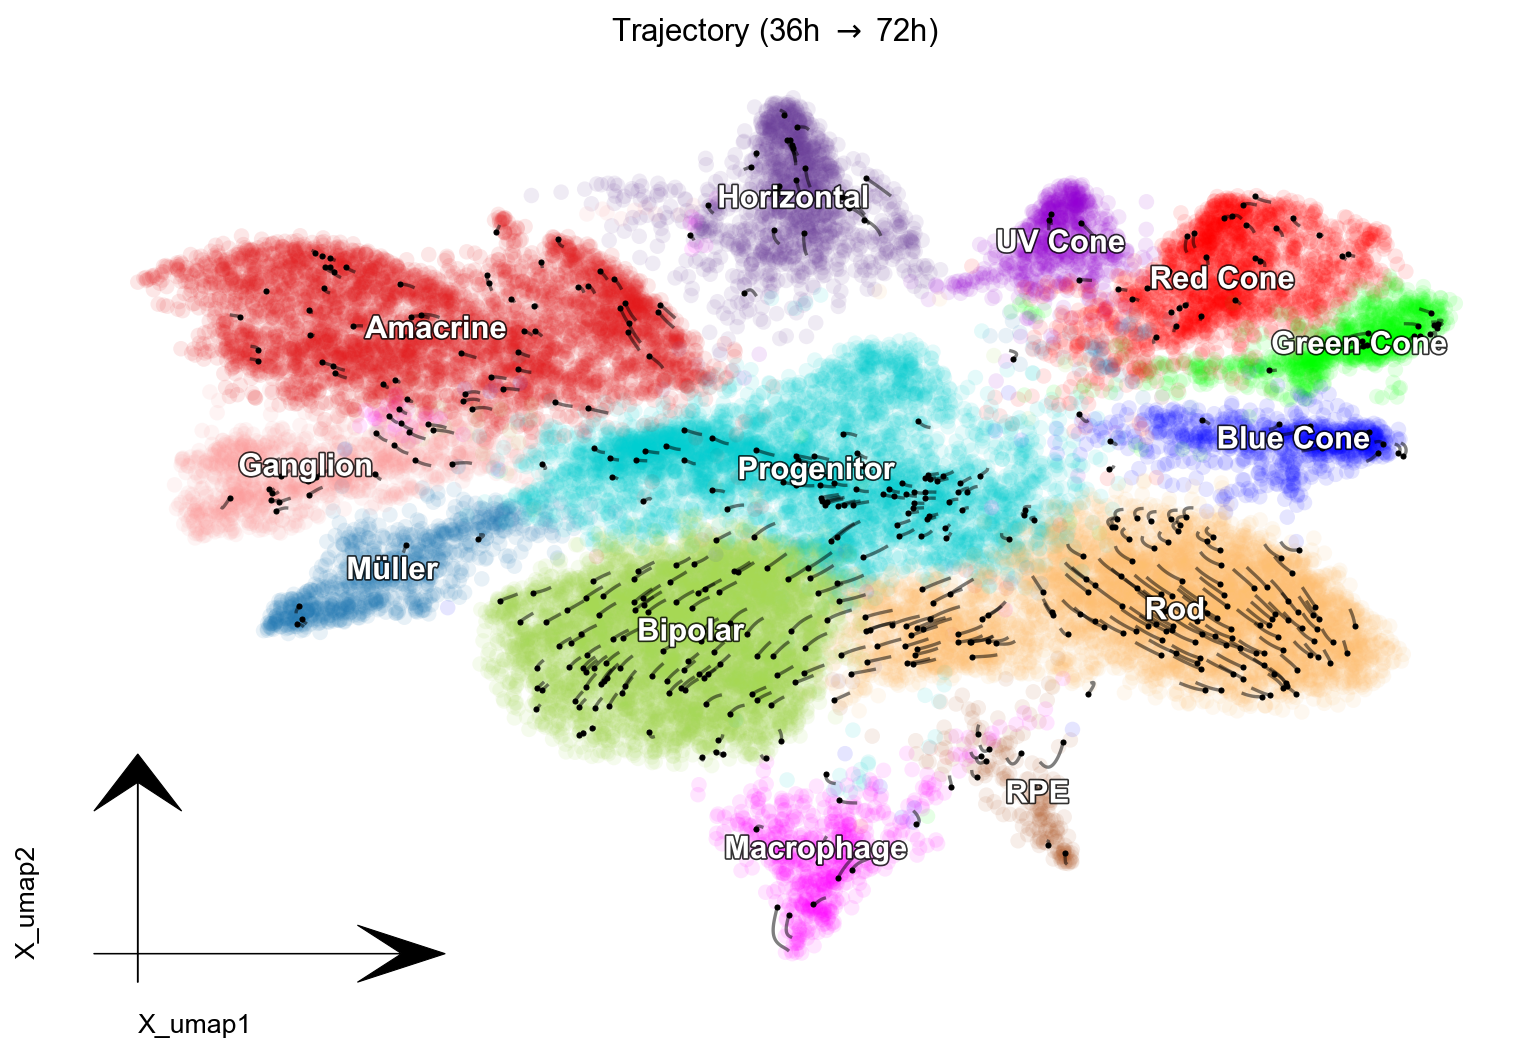

In [24]:
init_cells = adata_36.obsm['X_umap'][np.random.choice(adata_36.n_obs, 500, replace=False)]

paths = simulate_paths(
    init_cells, 
    adata_36.uns['VecFld_umap'], 
    adata_72.uns['VecFld_umap'],
    dt=0.01 * optimal_k)

fig, ax = plt.subplots(figsize=(12, 8))

dyn.pl.umap(adata_72, color='Cell_type', color_key=color_key_dict, ax=ax, alpha=0.1, pointsize=0.5, save_show_or_return='return')

for j in range(paths.shape[1]):
    plt.plot(paths[:, j, 0], paths[:, j, 1], color='k', alpha=0.5, linewidth=1.5)
    plt.scatter(paths[-1, j, 0], paths[-1, j, 1], color='k', s=5)

plt.title("Trajectory (36h $\\rightarrow$ 72h)")
plt.show()